# Test out source code

In [1]:
using Pkg 
pars = "RA_intermidiate"
Pkg.activate("../.")
include("../src/model.jl")
include("../parameters/$pars.jl")

  Activating project at `~/github/FisheriesInsuranceModel`
[ Info: Precompiling ValueFunctionIterations [dc40bd75-440c-4f41-8fab-869df1870d2c]
Precompiling StatsFunsChainRulesCoreExt
  ✓ StatsFuns → StatsFunsChainRulesCoreExt
  1 dependency successfully precompiled in 6 seconds. 23 already precompiled.
[ Info: Precompiling StatsFunsChainRulesCoreExt [d41313fe-2684-5453-9fef-703f5fa397f4]
┌ Warning: Module SpecialFunctionsChainRulesCoreExt with build ID fafbfcfd-b21a-2883-0002-a47ad659e14b is missing from the cache.
│ This may mean SpecialFunctionsChainRulesCoreExt [9eb7bdd4-e44c-55fc-b9cc-1a32cb715188] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
┌ Error: Error during loading of extension SpecialFunctionsChainRulesCoreExt of SpecialFunctions, use `Base.retry_load_extensions()` to retry.
│   exception =
│    1-element ExceptionStack:
│    Declaring __precompile__(false) is not allowed in files that are being precompiled.
│    Stacktrace

ComponentVector{Float64}(b0 = 1.0, g = 0.850441204540233, m̄ = 0.2, m̲ = 0.8931471805599454, r0 = 0.05505466645826072, z = 0.75, b_target = 0.4, b_limit = 0.2, f_target = 0.15870058672439358, T = [0.975 0.5; 0.025 0.5], σ_R = 0.75, μZ = 0.0, μ_P = 18.74677294892589, μ_Ce = 0.0, s̄ = -2.0, k = 0.0, y0 = 0.01, cf = 1.0e-6, cv = 0.0, κ_bankrupt = 0.01, γ = 1.001)

## Set up random variables

In [2]:
X, Xmc = init_ranom_variables(p;Nquad = 5)

(ValueFunctionIterations.RandomVariableFunction(var"#Xf#2"{RandomVariable}(RandomVariable([0.0 0.0 … 0.0 0.0; 18.74677294892589 18.74677294892589 … 18.74677294892589 18.74677294892589; … ; -2.142727510404604 -1.0167196349807006 … 1.0167196349807006 2.142727510404604; 0.25 0.25 … 0.9875 0.9875], [0.005628705663860333, 0.11103796100280622, 0.26666666666666694, 0.11103796100280622, 0.005628705663860333, 0.005347270380667317, 0.1054860629526659, 0.2533333333333336, 0.1054860629526659, 0.005347270380667317, 0.0002814352831930169, 0.005551898050140316, 0.013333333333333358, 0.005551898050140316, 0.0002814352831930169]))), MCRandomVariable(3, 4, [0.0 0.0 0.0; 18.74677294892589 18.74677294892589 18.74677294892589; … ; 0.4543223001660589 0.2461156625826892 -0.5402280839558146; 0.25 0.7375 0.9875], [0.5, 0.475, 0.025000000000000022], var"#sampler#3"{ComponentVector{Float64, Vector{Float64}, Tuple{Axis{(b0 = 1, g = 2, m̄ = 3, m̲ = 4, r0 = 5, z = 6, b_target = 7, b_limit = 8, f_target = 9, T = Vie

## Check simulation

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
[ Info: Precompiling SpecialFunctionsExt [997ecda8-951a-5f50-90ea-61382e97704b]
Precompiling FileIOExt
  ✓ Ghostscript_jll
  ✓ OpenSSL
  ✓ Latexify
  ✓ Latexify → SparseArraysExt
  ✓ Qt6ShaderTools_jll
  ✓ UnitfulLatexify
  ✓ Pango_jll
  ✓ Qt6Declarative_jll
  ✓ HTTP
  ✓ FileIO → HTTPExt
  ✓ Plots → UnitfulExt
  ✓ Plots → FileIOExt
  12 dependencies successfully precompiled in 127 seconds. 157 already precompiled.
[ Info: Precompiling FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c]
┌ Warning: Module Plots with build ID fafbfcfd-18ba-f739-0002-a487f2668a11 is missing from the cache.
│ This may mean Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c].
Precompiling IJuliaExt
  ✓ Plots → IJuliaExt
  1 dependency succes

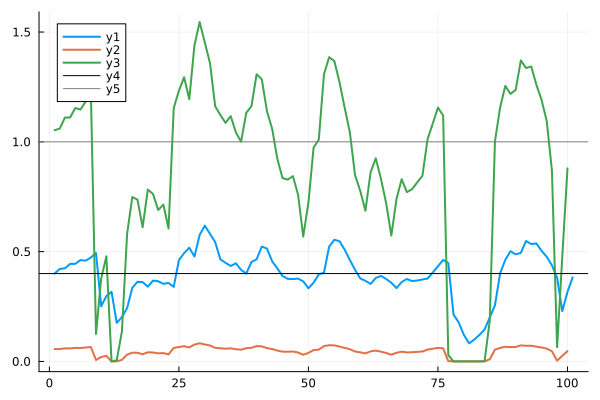

In [3]:
using Plots
X2, X2mc = init_ranom_variables(p;Nquad = 30)
states, m, f, h, y = simulate_trajectory(p,X2,100)
Plots.plot(exp.(states[1,:]), width = 2)
Plots.plot!(h, width = 2)
Plots.plot!(y, width = 2)
Plots.hline!([p.b_target], color = "black")
Plots.hline!([y_target], color = "grey")

## Check state grid

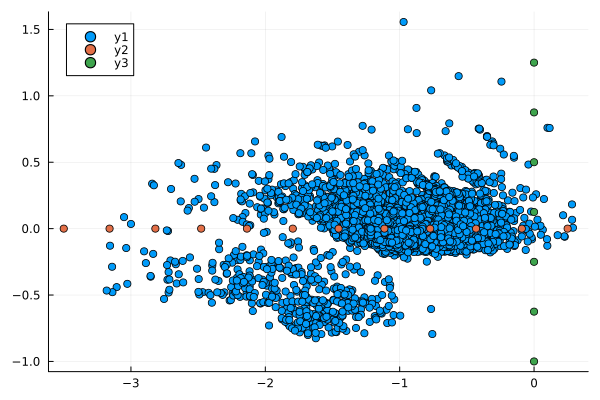

In [4]:
states, m, f, h, y = simulate_trajectory(p,X2,10000)
Plots.scatter(states[1,:], states[2,:])
bmax = 0.25; bmin = -3.5; Nb_grid = 12
b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
Δbmax = 1.25; Δbmin = -1.0; NΔb_grid = 7
Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
Plots.scatter!(b_grid,[0.0])
Plots.scatter!(zeros(length(Δb_grid)),Δb_grid)

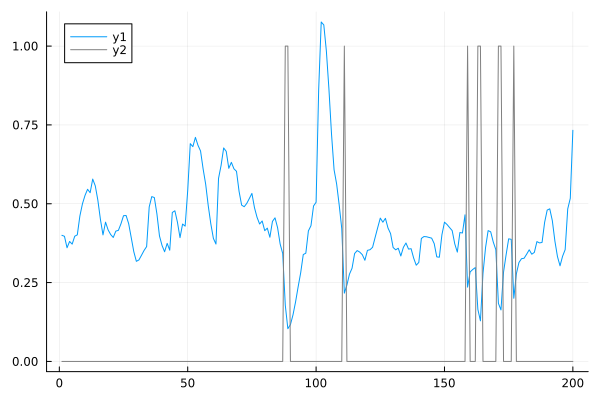

In [5]:
Plots.plot(exp.(states[1,1:200]))
Plots.plot!(states[3,1:200].-1, color = "grey")

## Define remaining state grids

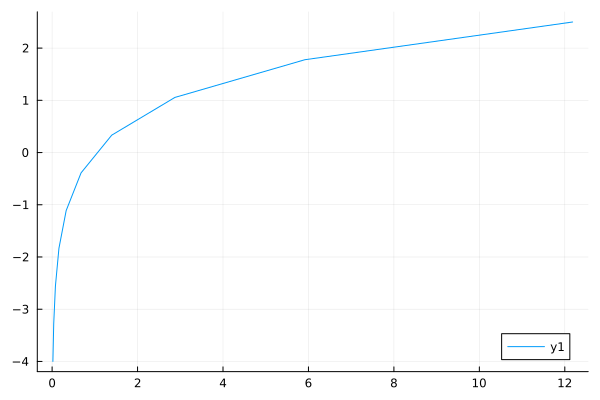

In [6]:
smax = 2.5; smin = -4.0; Ns_grid = 10
s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
Plots.plot(exp.(s_grid),s_grid)

In [7]:
state_grid = [s_grid,b_grid,Δb_grid]
nothing

## Define aciton grid 

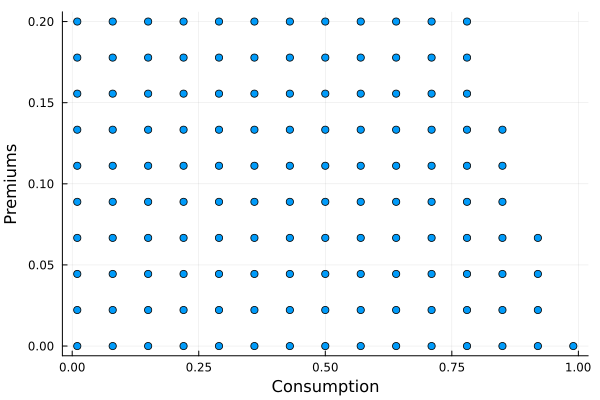

In [8]:
κmin = 0.01; κmax = 0.99; Nκ = 15
κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
ηmin = 0.0; ηmax=0.2; Nη = 10
η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
action_grid = [κ_grid,η_grid]

# plot grid
k=0; u_grid = zeros(2,length(κ_grid)*length(η_grid))
for (i,j) in Iterators.product(1:length(κ_grid),1:length(η_grid))
    k +=1
    u_grid[:,k] = vcat(κ_grid[i],η_grid[j]) 
end
u_grid=u_grid[:,reshape(mapslices(sum,u_grid,dims = 1).<=1,length(κ_grid)*length(η_grid))]
Plots.scatter(u_grid[1,:],u_grid[2,:], xlabel = "Consumption", ylabel= "Premiums", label = "")

# Define index and strike

# 

In [9]:
function strike(s,p)
    return 0.01 
end

function index(s,X)
    return s[3]-1
end 

index (generic function with 1 method)

## Set up model 

In [10]:
δ = 0.95
prob, El = init(action_grid,state_grid,δ,p,X,index,strike)
estimate_time(prob)

("Estimate (sec)" => 196.75, "One call" => 7.885932922363281e-6, "Number of computations" => 3326640, "actions" => "varaible", "states" => 1696, "random variable samples" => 15, "Estimated iterations" => 60, "Number of threads" => 8)

In [11]:
#load_solution(prob,"../results/$pars/sol.jld2")
solve!(prob,maxiter = 30)
nothing

Progress: 100%|█████████████████████████████████████████| Time: 0:02:32


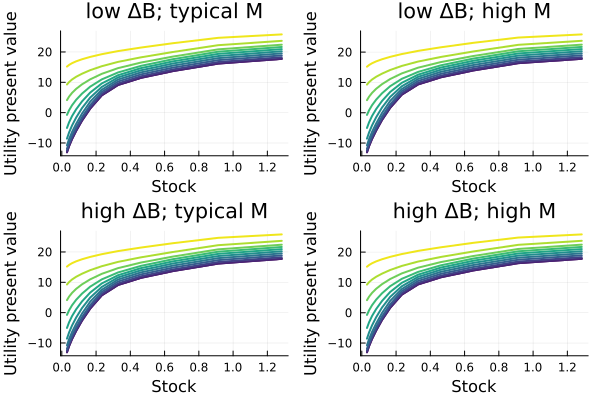

In [13]:
#include("../src/plotting.jl")
plot_value_function(prob)

In [14]:
pkgversion(ValueFunctionIterations)

v"0.7.7"

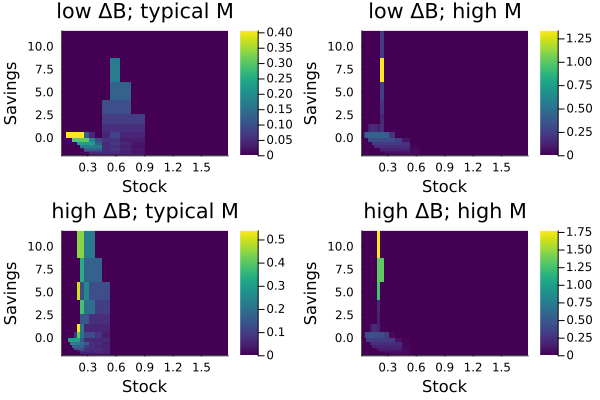

In [290]:
include("../src/plotting.jl")
plot_premiums(prob)

In [291]:
prob.F([1.0,0.0,log(0.3),0.0,1.0],[0.01,0.1],[0.5,0.5,0.4,0.0,1.0],prob.p)

5-element Vector{Float64}:
  1.0
 -0.5595416239229255
 -1.7617332854003491
 -0.557760481074413
  2.0

Seed: 798


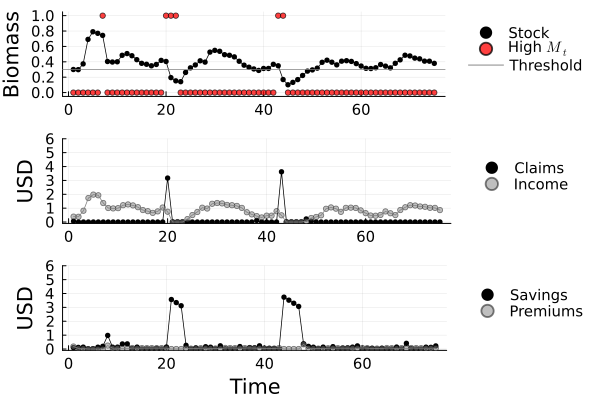

In [292]:
include("../src/plotting.jl")
using Random
seed = rand(1:1000)
#Seed: 331; Seed: 361; Seed: 524; and Seed: 232; T = 100
Random.seed!(232); println("Seed: ", seed) # "random" seed = 623
x=simulation(prob,El,Xmc,76;with_policy = false, s0 = [1.0,0.0,log(0.3),0.0,1.0])
plot_simulation(x,max_USD=6.0,max_Bt=1.0,T = 75)

In [266]:
include("../src/model.jl")
pars = "no_RA_intermidiate_higher_k_2"
include("../parameters/$pars.jl")

ComponentVector{Float64}(b0 = 1.0, g = 0.850441204540233, m̄ = 0.2, m̲ = 0.8931471805599454, r0 = 0.05505466645826072, z = 0.75, b_target = 0.4, b_limit = 0.2, f_target = 0.15870058672439358, T = [0.975 0.5; 0.025 0.5], σ_R = 0.75, μZ = 0.0, μ_P = 18.74677294892589, μ_Ce = 0.0, s̄ = -2.0, k = 0.04, y0 = -0.25, cf = 1.0e-6, cv = 0.0, κ_bankrupt = 0.01, γ = 0.0)

In [271]:
function mask_to_vspans(x::AbstractVector, mask::AbstractVector{<:Integer})
    @assert length(x) == length(mask) "x and mask must be the same length"
    spans = []
    n = length(mask)
    i = 1
    while i <= n
        if mask[i] == 1
            j = i
            while j <= n && mask[j] == 1
                j += 1
            end
            # run of ones is i:(j-1)
            push!(spans, [x[i], x[j-1]+1.0])
            i = j
        else
            i += 1
        end
    end
    return spans
end

mask_to_vspans (generic function with 1 method)

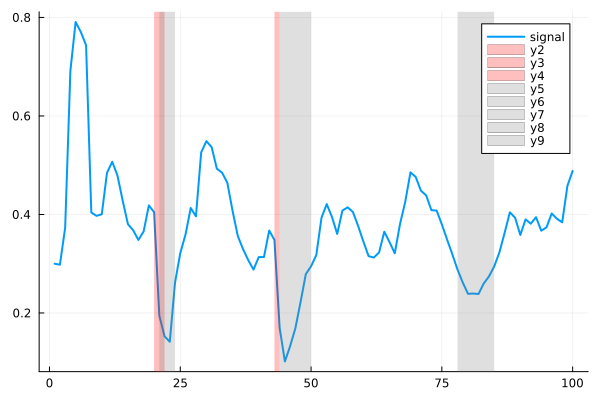

In [251]:
xt = 1:length(x.mt)
spans1 = mask_to_vspans(xt, x.mt .> 0.5)
spans2 = mask_to_vspans(xt, x.bt .< 0.3)
plot(xt, x.bt, lw=2, label="signal")
vspan!(spans1, fillalpha=0.25, fillcolor=:red, linealpha=0)
vspan!(spans2, fillalpha=0.25, fillcolor=:grey, linealpha=0)

In [190]:
# 0.0016 (0.0008, 0.0024)
# 0.0036 (0.0023, 0.0049)
println("Long life history (with)")
println("mean estiate: ", round(100*(1-(1-0.0016)^10), digits=2))
println("lower bound: ", round(100*(1-(1-0.0008)^10), digits=2))
println("upper bound: ", round(100*(1-(1-0.0024)^10), digits=2))
println("Long life history (without)")
println("mean estiate: ", round(100*(1-(1-0.0036)^10), digits=2))
println("lower bound: ", round(100*(1-(1-0.0023)^10), digits=2))
println("upper bound: ", round(100*(1-(1-0.0049)^10), digits=2))

Long life history (with)
mean estiate: 1.59
lower bound: 0.8
upper bound: 2.37
Long life history (without)
mean estiate: 3.54
lower bound: 2.28
upper bound: 4.79


In [191]:
1.59/3.54

0.4491525423728814